In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("tf.keras module:", keras.__name__)


Python: 3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]
TensorFlow: 2.15.1
tf.keras module: keras.api._v2.keras


In [2]:
from pathlib import Path

MODEL_PATH   = Path("model82.h5")
WEIGHTS_PATH = Path("model82_weights.h5")

IG_FILE  = Path("sub-33_face_avg_IG.nii.gz")
FFA_FILE = Path("face ffa_association-test_z_FDR_0.01.nii")

FMRI_FILE   = Path("sub-80_task-littlemisssunshine_bold_preprocessedICA.nii.gz") 
MASK_PATH   = Path("85_subBrainMask_average_99.nii.gz")                           
EVENTS_FILE = Path("task-littlemisssunshine_face-annotation.txt")        

# Outputs
IG_DIR = Path("IG")
RESULTS_DIR = Path("results")
IG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
assert MODEL_PATH.exists(), f"Missing: {MODEL_PATH.resolve()}"

model = keras.models.load_model(MODEL_PATH, compile=False)
print("Loaded model:", MODEL_PATH.resolve())

if WEIGHTS_PATH.exists():
    model.load_weights(WEIGHTS_PATH)
    print("Loaded weights:", WEIGHTS_PATH.resolve())

model.summary()


The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
Loaded model: /Users/saraasadi/Desktop/fnof/model82.h5
Loaded weights: /Users/saraasadi/Desktop/fnof/model82_weights.h5
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 41489, 10, 64)     1024      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 41489, 10, 64)     0         
                                                                 
 batch_normalization (Batch  (None, 41489, 10, 64)     256       
 Normalization)                                        

In [4]:
#unseen input
NPY_FILE = Path("sub-2_task-500daysofsummer_face-254.npy")
assert NPY_FILE.exists(), f"Missing: {NPY_FILE.resolve()}"

# Load
X2D = np.load(NPY_FILE)
print("Loaded shape:", X2D.shape)   # (voxels, WIN)

assert X2D.ndim == 2, "Expected 2D array: (voxels, time)"

# Add batch + channel dims
# (1, vox, WIN, 1)
X = X2D[np.newaxis, ..., np.newaxis].astype(np.float32)

print("Model input shape:", X.shape)


#running prediction on this unseen input 
pred = model.predict(X, verbose=0).item()

binary_pred = int(pred >= 0.5)

print(f"Predicted probability (face): {pred:.4f}")
print(f"Binary prediction (>=0.5): {binary_pred}")


Loaded shape: (41489, 10)
Model input shape: (1, 41489, 10, 1)
Predicted probability (face): 0.9673
Binary prediction (>=0.5): 1


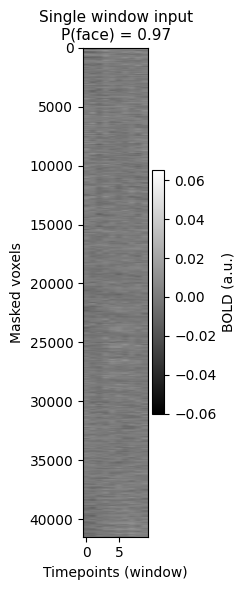

In [5]:
#Visualize the input window
plt.figure(figsize=(2.5, 6))
plt.imshow(X2D, aspect="auto", cmap="grey")
plt.colorbar(label="BOLD (a.u.)")
plt.xlabel("Timepoints (window)")
plt.ylabel("Masked voxels")
plt.title(
    f"Single window input\nP(face) = {pred:.2f}",
    fontsize=11
)
plt.tight_layout()
plt.show()

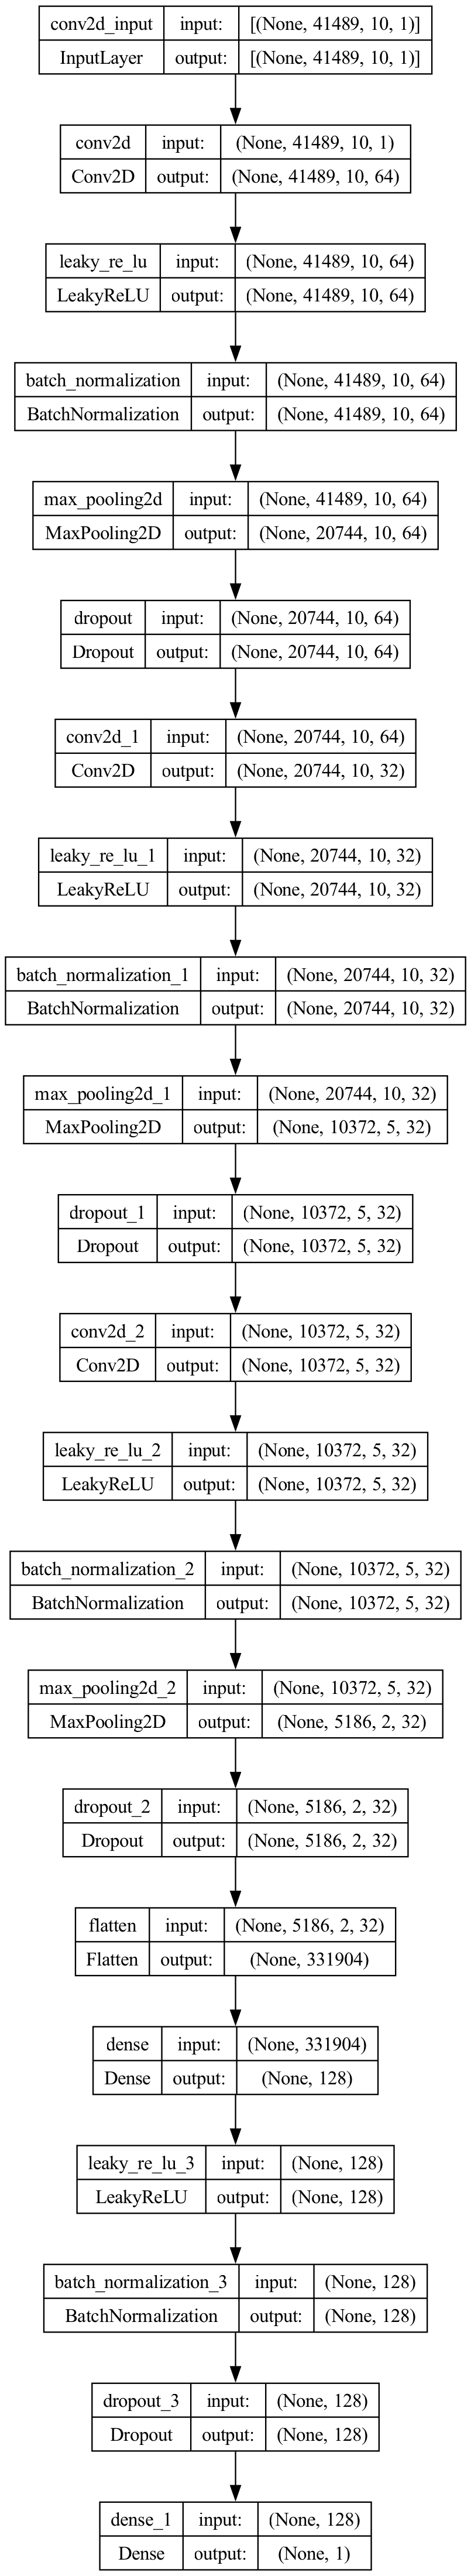

Saved: /Users/saraasadi/Desktop/fnof/results/model_arch.png


In [7]:
# Plot model architecture 
from IPython.display import Image, display

try:
    from tensorflow.keras.utils import plot_model


    arch_png = RESULTS_DIR / "model_arch.png"
    plot_model(
        model,
        to_file=str(arch_png),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=170,
    )
    display(Image(filename=str(arch_png)))
    print("Saved:", arch_png.resolve())
except Exception as e:
    print("Could not plot model architecture (pydot/graphviz issue?):", e)


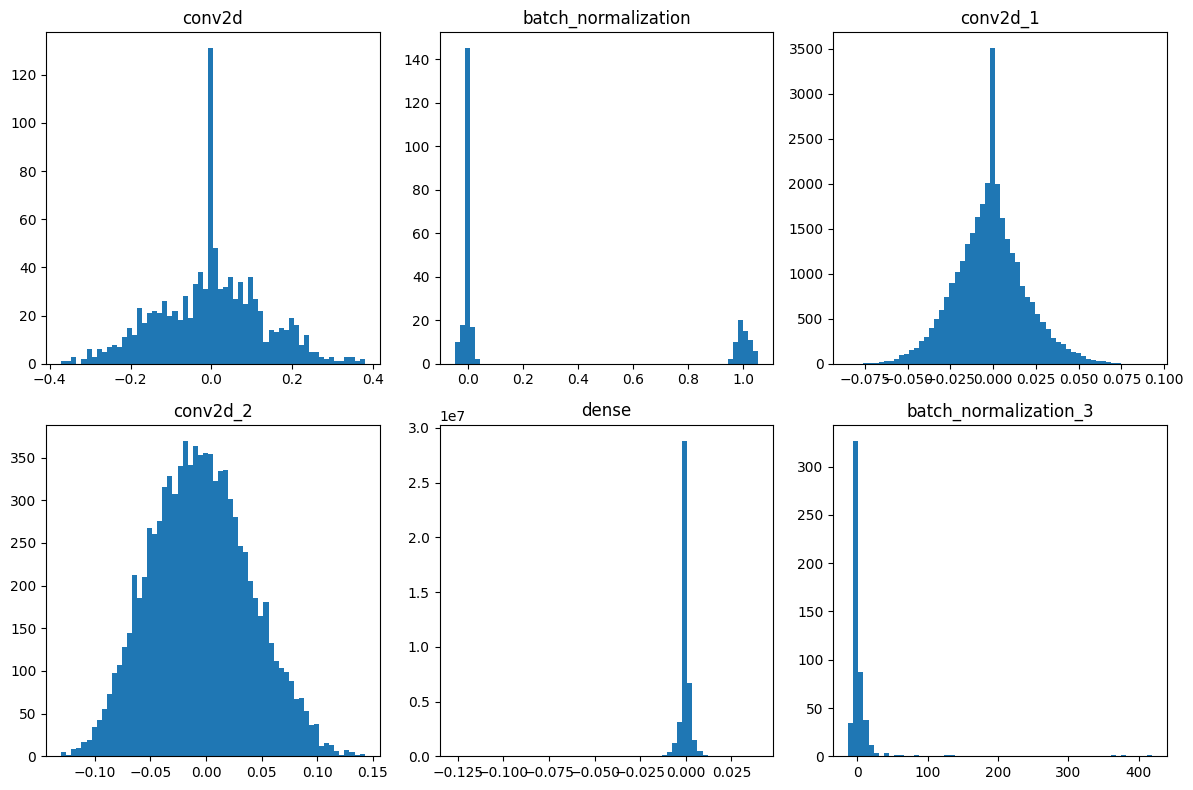

Saved: /Users/saraasadi/Desktop/fnof/results/top_layer_weight_hists.png


In [8]:
# Plot weight histograms for top-k param layers
def layer_param_count(layer) -> int:
    n = 0
    for w in layer.get_weights():
        if w is not None:
            n += int(np.prod(w.shape))
    return n

layers_with_counts = [(layer.name, layer_param_count(layer)) for layer in model.layers]
layers_with_counts.sort(key=lambda x: x[1], reverse=True)
layer_names_sorted = [name for name, cnt in layers_with_counts]

top_k = 6
top_layers = set(layer_names_sorted[: min(top_k, len(layer_names_sorted))])

fig = plt.figure(figsize=(12, 8))
plot_i = 1
for layer in model.layers:
    if layer.name not in top_layers:
        continue
    wts = layer.get_weights()
    if not wts:
        continue

    w_flat_parts = []
    for w in wts:
        if w is None:
            continue
        w = np.asarray(w)
        if w.size == 0:
            continue
        w_flat_parts.append(w.reshape(-1))

    if not w_flat_parts:
        continue

    w_flat = np.concatenate(w_flat_parts, axis=0)

    ax = fig.add_subplot(2, 3, plot_i)
    ax.hist(w_flat, bins=60)
    ax.set_title(layer.name)
    plot_i += 1
    if plot_i > 6:
        break

plt.tight_layout()
hist_png = RESULTS_DIR / "top_layer_weight_hists.png"
plt.savefig(hist_png, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", hist_png.resolve())

## IG visualization for a single trial

In [9]:
if not IG_FILE.exists():
    raise FileNotFoundError(f"IG_FILE not found: {IG_FILE.resolve()}")
if not FFA_FILE.exists():
    raise FileNotFoundError(f"FFA_FILE not found: {FFA_FILE.resolve()}")

import shutil

ffa_dst = IG_DIR / "ffa_association-test_z_FDR_0.01.nii"
ig_dst  = IG_DIR / "IG_input.nii.gz"

shutil.copy2(str(FFA_FILE), str(ffa_dst))
shutil.copy2(str(IG_FILE), str(ig_dst))

print("\nIG/ paths ready:")
print(" -", ffa_dst.resolve())
print(" -", ig_dst.resolve())

# Parameters 
ffa_threshold = 0.4
erosion_iter = 2
display_percentile = 0
cmap = "RdBu"
out_png_base = "no-threshold-ventral"
subject_label = "Subject 33"

temp_dir = IG_DIR / "temp_surf_images"
temp_dir.mkdir(exist_ok=True)

data_paths = {"IG Map": ig_dst}
ffa_mask_path = str(ffa_dst)


IG/ paths ready:
 - /Users/saraasadi/Desktop/fnof/IG/ffa_association-test_z_FDR_0.01.nii
 - /Users/saraasadi/Desktop/fnof/IG/IG_input.nii.gz



 IG shape: (85, 85, 85, 10)
Saved: /Users/saraasadi/Desktop/fnof/IG/no-threshold-ventral_IG Map.png


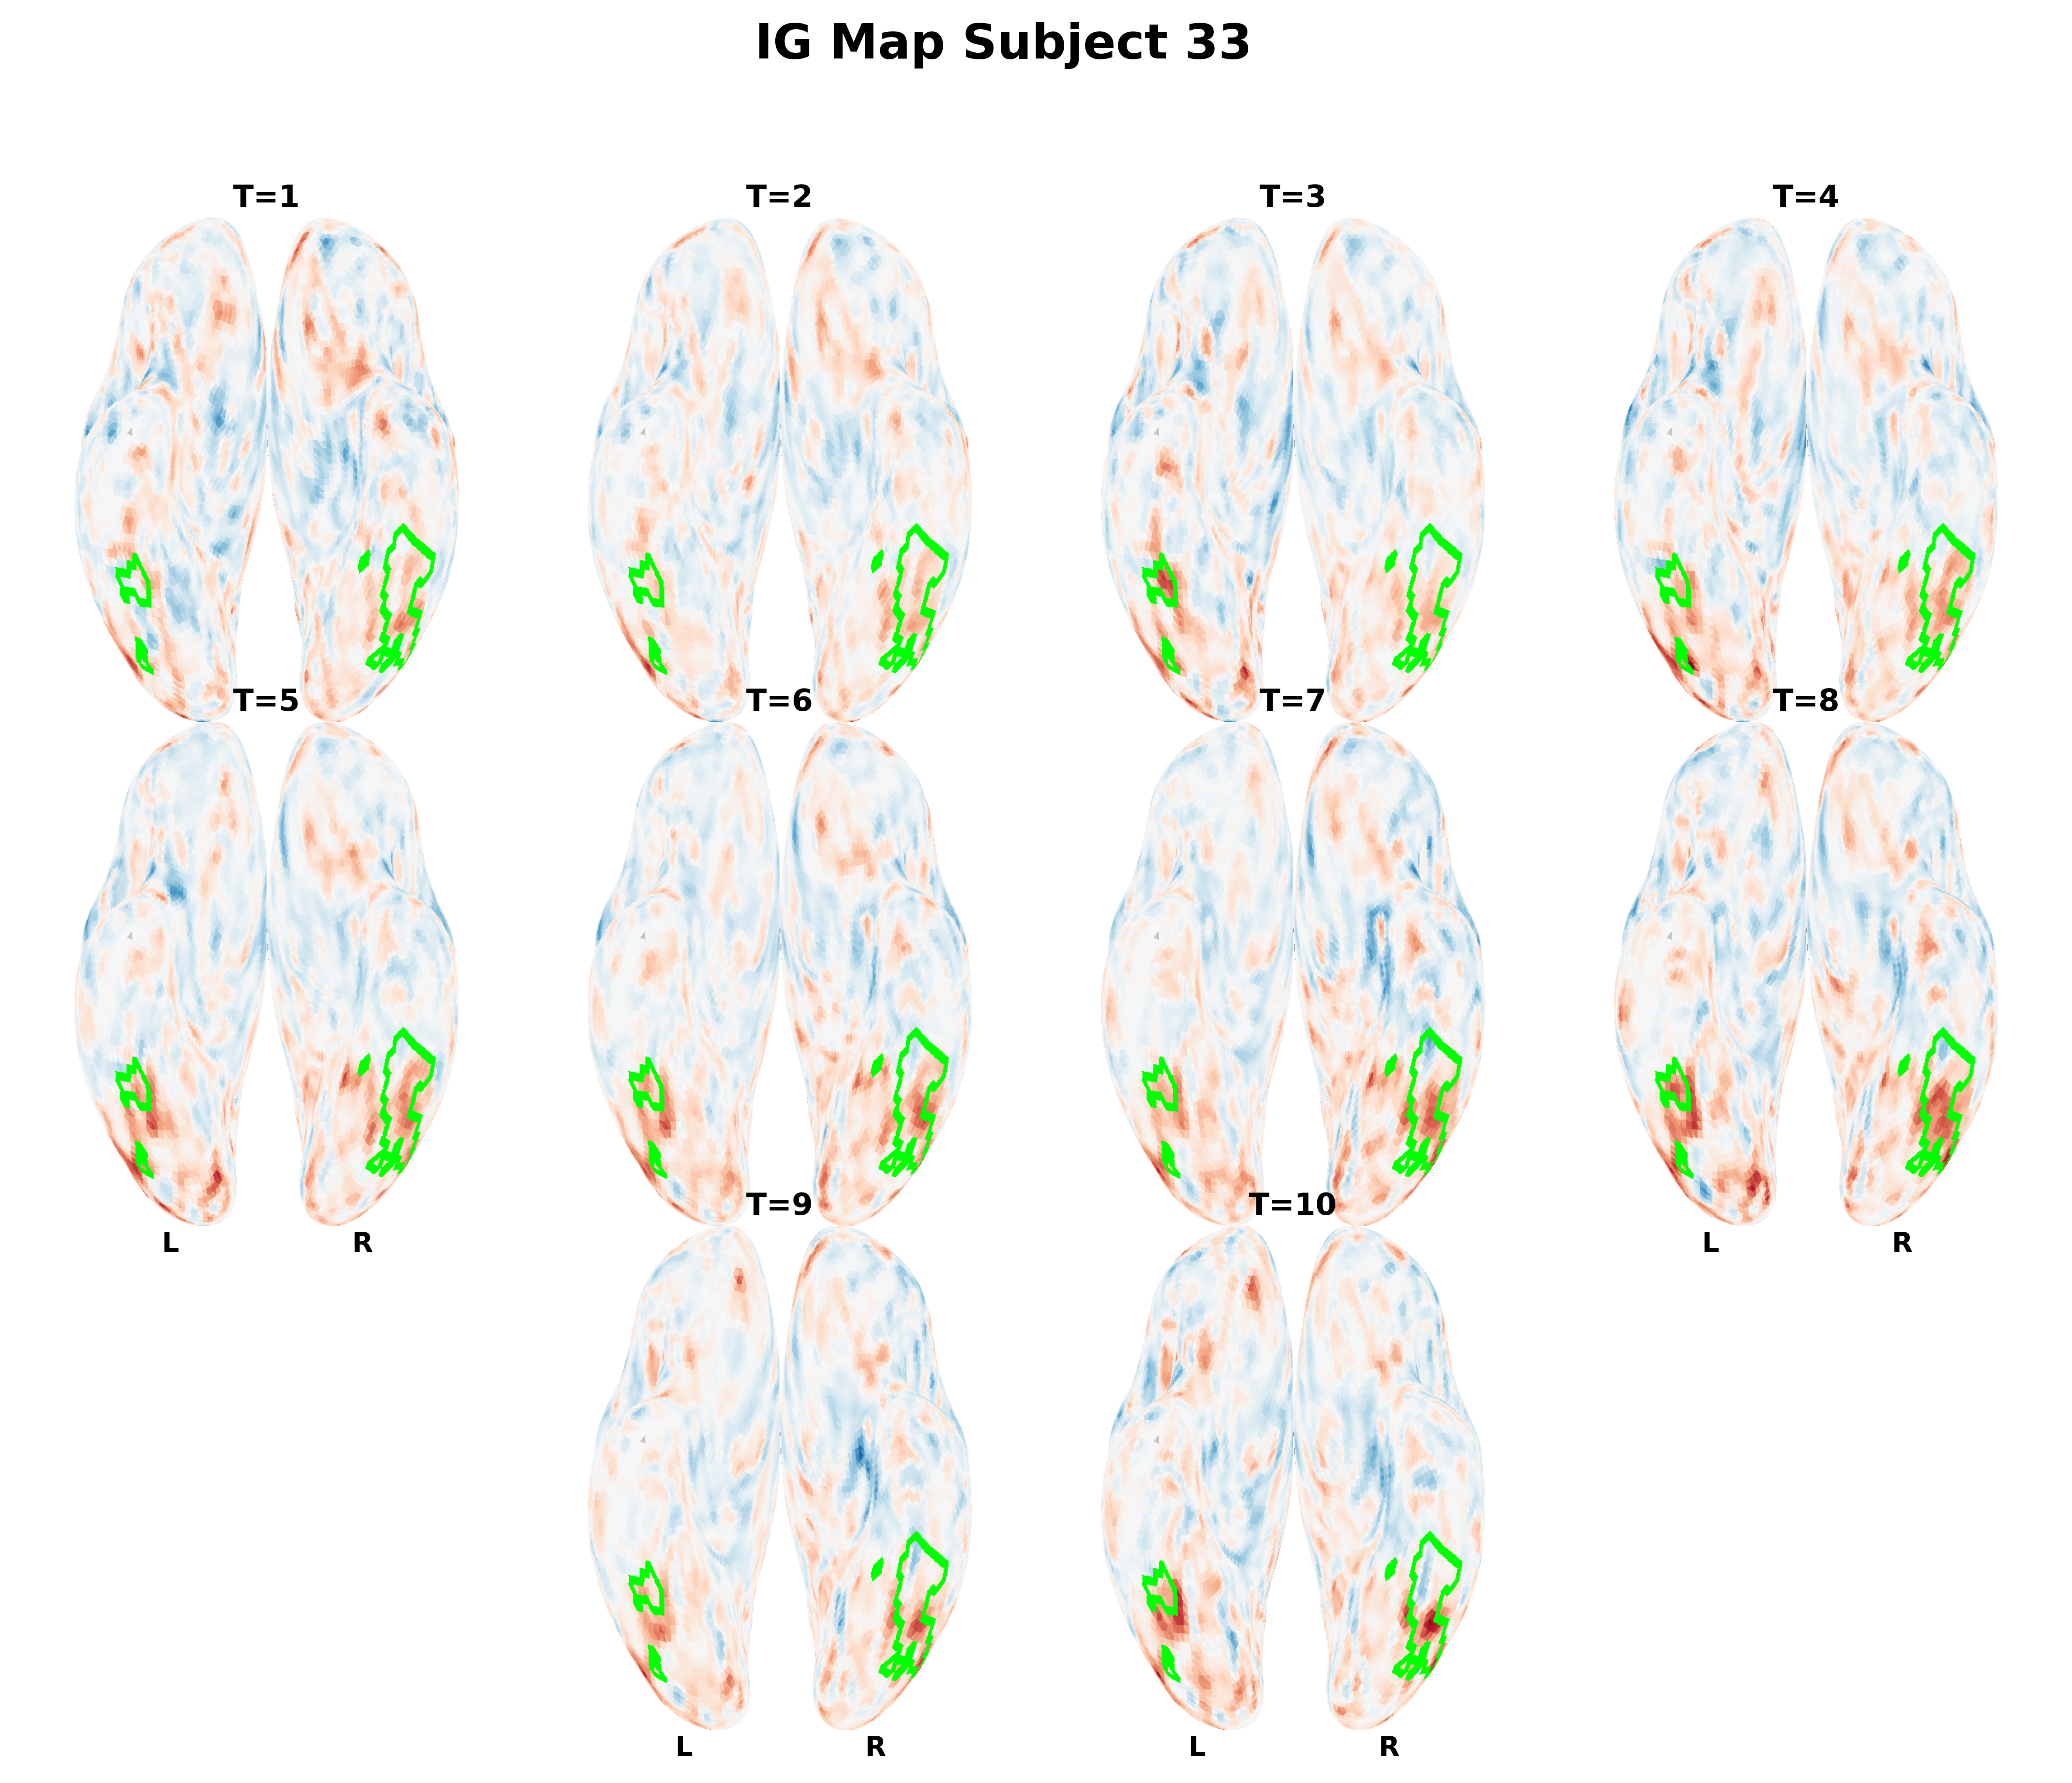

In [10]:
import nibabel as nib
from nilearn import datasets, plotting, surface, image
from scipy.ndimage import binary_erosion

# helpers 
def load_imgs(paths_dict):
    return {name: nib.load(str(p)) for name, p in paths_dict.items()}

def make_eroded_mask(mask_file, iterations):
    mimg = nib.load(mask_file)
    mask = mimg.get_fdata() > 0
    erode = binary_erosion(mask, iterations=iterations)
    return nib.Nifti1Image(erode.astype(float), mimg.affine)

def proj_mask_to_surf(mask_img, fs, hemi):
    mesh = fs.pial_left if hemi == "left" else fs.pial_right
    proj = surface.vol_to_surf(mask_img, mesh, interpolation="nearest_most_frequent")
    return (proj > ffa_threshold).astype(float)

def proj_vol_to_surf_t(nii4d, t, fs, hemi):
    mesh = fs.pial_left if hemi == "left" else fs.pial_right
    return surface.vol_to_surf(image.index_img(nii4d, t), mesh)

def crop_whitespace(rgb):
    img = np.fliplr(np.rot90(rgb, 3))
    gray = img.mean(axis=2)
    keep = gray < 0.98
    if not np.any(keep):
        return img
    ys, xs = np.where(keep)
    return img[ys.min():ys.max() + 1, xs.min():xs.max() + 1, :]

def surf_figure(fs, hemi, tex, thresh, title=None):
    infl = fs.infl_left if hemi == "left" else fs.infl_right
    sulc = fs.sulc_left if hemi == "left" else fs.sulc_right
    fig = plotting.plot_surf_stat_map(
        infl, tex, hemi=hemi, view="ventral",
        threshold=thresh, cmap=cmap, bg_map=sulc,
        colorbar=False, figure=plt.figure(dpi=150)
    )
    if title:
        fig.axes[0].set_title(title, fontsize=10)
    return fig

def add_mask_contour(fs, hemi, mask_vertices, fig):
    if np.count_nonzero(mask_vertices) == 0:
        return
    infl = fs.infl_left if hemi == "left" else fs.infl_right
    try:
        plotting.plot_surf_contours(
            infl, mask_vertices,
            levels=[1], colors=["lime"],
            linewidths=0.005, figure=fig
        )
    except ValueError:
        plotting.plot_surf_stat_map(
            infl, mask_vertices, hemi=hemi, view="ventral",
            threshold=0.5, cmap="Greens", alpha=0.1,
            colorbar=False, figure=fig
        )

def safe_percentile(arr, p):
    arr = np.asarray(arr)
    arr = arr[np.nonzero(arr)]
    return float(np.percentile(np.abs(arr), p)) if arr.size else 0.0

#  run 
fs = datasets.fetch_surf_fsaverage()
imgs = load_imgs(data_paths)

print("\n IG shape:", imgs["IG Map"].shape)
n_tp = imgs["IG Map"].shape[-1]

ffa_mask_img = make_eroded_mask(ffa_mask_path, erosion_iter)
ffa_surf = {hemi: proj_mask_to_surf(ffa_mask_img, fs, hemi) for hemi in ("left", "right")}

saved_files = []

for cond, nii in imgs.items():
    ncols = int(np.ceil(np.sqrt(n_tp)))
    nrows = int(np.ceil(n_tp / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3 * ncols, 3 * nrows),
        gridspec_kw={"wspace": 0.05, "hspace": 0.0}
    )

    if n_tp == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    fig.suptitle(f"{cond} {subject_label}", fontsize=16, fontweight="bold", y=0.98)

    items_in_last_row = n_tp % ncols if n_tp % ncols != 0 else ncols
    last_row_start_col = (ncols - items_in_last_row) // 2

    for t in range(n_tp):
        row = t // ncols
        col = t % ncols
        if row == nrows - 1 and items_in_last_row < ncols:
            col += last_row_start_col

        crops = []
        for hemi in ("left", "right"):
            tex = proj_vol_to_surf_t(nii, t, fs, hemi)
            thresh = safe_percentile(tex, display_percentile)
            f = surf_figure(fs, hemi, tex, thresh)
            add_mask_contour(fs, hemi, ffa_surf[hemi], f)

            tmp = temp_dir / f"{cond}_{hemi}_t{t}.png"
            plt.savefig(tmp, bbox_inches="tight")
            plt.close()

            rgb = plt.imread(tmp)[..., :3]
            crops.append(crop_whitespace(rgb))

        h = min(c.shape[0] for c in crops)
        w = min(c.shape[1] for c in crops)
        crops = [c[:h, :w] for c in crops]
        panel = np.concatenate(crops, axis=1)

        ax = axes[row, col]
        ax.imshow(panel)
        ax.axis("off")
        ax.text(0.5, 1.01, f"T={t+1}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", transform=ax.transAxes)
        ax.text(0.25, -0.01, "L", ha="center", va="top",
                fontsize=9, fontweight="bold", transform=ax.transAxes)
        ax.text(0.75, -0.01, "R", ha="center", va="top",
                fontsize=9, fontweight="bold", transform=ax.transAxes)

    # turn off unused axes
    for r in range(nrows):
        for c in range(ncols):
            if not axes[r, c].has_data():
                axes[r, c].axis("off")

    out_file = IG_DIR / f"{out_png_base}_{cond}.png"
    fig.savefig(out_file, dpi=500, bbox_inches="tight")
    plt.close(fig)

    print("Saved:", out_file.resolve())
    saved_files.append(out_file)

# cleanup temp images
for p in temp_dir.glob("*.png"):
    p.unlink()
try:
    temp_dir.rmdir()
except OSError:
    pass

# Display results in notebook
for f in saved_files:
    display(Image(filename=str(f)))


## Moment-by-moment full movie

In [16]:
import numpy as np
import nibabel as nib
from pathlib import Path

FMRI_FILE = Path("sub-80_task-littlemisssunshine_bold_preprocessedICA.nii.gz")  
MASK_PATH = Path("85_subBrainMask_average_99.nii.gz")

TR = 1.0
LAG = 4
MASK_THRESH = 0.99

# Time range (seconds)
SEC_START = 2000
SEC_END   = 4000

# Chunk size (TRs per read)
CHUNK_TR = 50


In [17]:
mask_img = nib.load(str(MASK_PATH))
mask_data = mask_img.get_fdata(dtype=np.float32)

mask_idx = np.where(mask_data.reshape(-1) > MASK_THRESH)[0]
n_vox = int(mask_idx.size)

print("Mask voxels kept:", n_vox)
if n_vox == 0:
    raise ValueError(f"No voxels kept at MASK_THRESH={MASK_THRESH}")


Mask voxels kept: 41489


In [18]:
img = nib.load(str(FMRI_FILE))
X, Y, Z, T = img.shape
print("fMRI shape:", (X, Y, Z, T))

t_start = int(SEC_START / TR)
t_end   = int(SEC_END   / TR)

if t_start < 0 or t_end > T or t_start >= t_end:
    raise ValueError(f"Bad time range: {t_start}:{t_end} for T={T}")

bold_start = int(round(LAG / TR))
t_start_lagged = t_start + bold_start

if t_start_lagged >= t_end:
    raise ValueError("Lag pushes start beyond selected range")

T_sel = t_end - t_start_lagged

print(f"Using seconds {SEC_START}–{SEC_END} -> indices {t_start}:{t_end}")
print(f"Applying lag {LAG}s -> start index {t_start_lagged}")
print("Timepoints after lag:", T_sel)


fMRI shape: (85, 85, 85, 5900)
Using seconds 2000–4000 -> indices 2000:4000
Applying lag 4s -> start index 2004
Timepoints after lag: 1996


In [19]:
masked_full = np.empty((n_vox, T_sel), dtype=np.float32)

col = 0
for t0 in range(t_start_lagged, t_end, CHUNK_TR):
    t1 = min(t_end, t0 + CHUNK_TR)

    slab = img.slicer[:, :, :, t0:t1].get_fdata(dtype=np.float32)  # (X,Y,Z,chunk)
    slab2d = slab.reshape(-1, slab.shape[-1])                      # (XYZ,chunk)

    masked_full[:, col:col + slab2d.shape[1]] = slab2d[mask_idx, :]
    col += slab2d.shape[1]

    print(f"Loaded {t0}:{t1}  -> slab {slab.shape}")

print("masked_full shape:", masked_full.shape)  # (vox_kept, T_sel)


Loaded 2004:2054  -> slab (85, 85, 85, 50)
Loaded 2054:2104  -> slab (85, 85, 85, 50)
Loaded 2104:2154  -> slab (85, 85, 85, 50)
Loaded 2154:2204  -> slab (85, 85, 85, 50)
Loaded 2204:2254  -> slab (85, 85, 85, 50)
Loaded 2254:2304  -> slab (85, 85, 85, 50)
Loaded 2304:2354  -> slab (85, 85, 85, 50)
Loaded 2354:2404  -> slab (85, 85, 85, 50)
Loaded 2404:2454  -> slab (85, 85, 85, 50)
Loaded 2454:2504  -> slab (85, 85, 85, 50)
Loaded 2504:2554  -> slab (85, 85, 85, 50)
Loaded 2554:2604  -> slab (85, 85, 85, 50)
Loaded 2604:2654  -> slab (85, 85, 85, 50)
Loaded 2654:2704  -> slab (85, 85, 85, 50)
Loaded 2704:2754  -> slab (85, 85, 85, 50)
Loaded 2754:2804  -> slab (85, 85, 85, 50)
Loaded 2804:2854  -> slab (85, 85, 85, 50)
Loaded 2854:2904  -> slab (85, 85, 85, 50)
Loaded 2904:2954  -> slab (85, 85, 85, 50)
Loaded 2954:3004  -> slab (85, 85, 85, 50)
Loaded 3004:3054  -> slab (85, 85, 85, 50)
Loaded 3054:3104  -> slab (85, 85, 85, 50)
Loaded 3104:3154  -> slab (85, 85, 85, 50)
Loaded 3154

In [20]:
print("dtype:", masked_full.dtype)
print("min/max:", float(masked_full.min()), float(masked_full.max()))
print("NaNs:", int(np.isnan(masked_full).sum()))

dtype: float32
min/max: -0.10590135306119919 0.12002453207969666
NaNs: 0


In [21]:
WIN  = 10
STEP = 1

n_time = masked_full.shape[1]
if n_time < WIN:
    raise ValueError(f"Not enough timepoints: have {n_time}, need WIN={WIN}")

N = (n_time - WIN) // STEP + 1
windows = np.empty((N, masked_full.shape[0], WIN), dtype=np.float32)

times = np.empty((N,), dtype=float)
base_time_sec = t_start_lagged * TR  # window time axis starts here

i = 0
for t0 in range(0, n_time - WIN + 1, STEP):
    windows[i] = masked_full[:, t0:t0 + WIN]
    times[i] = base_time_sec + t0 * TR
    i += 1

windows = windows[..., np.newaxis]  # (N, vox, WIN, 1)

print("windows shape:", windows.shape)
print("times range:", float(times.min()), "->", float(times.max()))


windows shape: (1987, 41489, 10, 1)
times range: 2004.0 -> 3990.0


In [22]:
PRED_THRESH = 0.5
BATCH_SIZE = 64

preds = model.predict(windows, batch_size=BATCH_SIZE, verbose=1).reshape(-1)
binary_preds = (preds >= PRED_THRESH).astype(int)

print("preds shape:", preds.shape)
print("binary_preds counts:", np.bincount(binary_preds))


32/32 [==============================] - 148s 4s/step
preds shape: (1987,)
binary_preds counts: [ 708 1279]


In [24]:
EVENTS_FILE = Path("task-littlemisssunshine_face-annotation.txt")
assert EVENTS_FILE.exists(), f"Missing: {EVENTS_FILE.resolve()}"

def load_events_2col(path: Path):
    text = path.read_text(errors="ignore").splitlines()
    rows = []
    for line in text:
        line = line.strip()
        if not line:
            continue
        if line.startswith(("#", "//")):
            continue
        low = line.lower()
        if "onset" in low and "duration" in low:
            continue

        parts = line.replace(",", " ").split()
        if len(parts) < 2:
            continue
        try:
            onset = float(parts[0])
            dur   = float(parts[1])
            rows.append((onset, dur))
        except ValueError:
            continue

    if len(rows) == 0:
        raise ValueError(f"No valid onset/duration rows found in {path}")

    arr = np.array(rows, dtype=float)
    return arr[:, 0], arr[:, 1]

def create_ground_truth_timeline(onsets, durations, t_axis):
    gt = np.zeros(len(t_axis), dtype=int)
    for onset, dur in zip(onsets, durations):
        end = onset + dur
        idx = np.where((t_axis >= onset) & (t_axis < end))[0]
        gt[idx] = 1
    return gt

gt_onsets, gt_durations = load_events_2col(EVENTS_FILE)

# shift onsets by LAG to align with BOLD
gt_onsets_lagged = gt_onsets + LAG

# build GT for ONLY the window times we created (already 2000–4000 segment)
gt_binary = create_ground_truth_timeline(gt_onsets_lagged, gt_durations, times)

print("GT positives:", int(gt_binary.sum()), "out of", len(gt_binary))
print("GT counts:", np.bincount(gt_binary))


GT positives: 1633 out of 1987
GT counts: [ 354 1633]


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(gt_binary, binary_preds, zero_division=0)
recall    = recall_score(gt_binary, binary_preds, zero_division=0)
f1        = f1_score(gt_binary, binary_preds, zero_division=0)

print("METRICS on 2000–4000s segment")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

np.save(RESULTS_DIR / "times_2000_4000.npy", times)
np.save(RESULTS_DIR / "preds_2000_4000.npy", preds)
np.save(RESULTS_DIR / "binary_preds_2000_4000.npy", binary_preds)
np.save(RESULTS_DIR / "gt_binary_2000_4000.npy", gt_binary)

(Path(RESULTS_DIR) / "metrics_2000_4000.txt").write_text(
    f"Precision: {precision:.6f}\nRecall: {recall:.6f}\nF1: {f1:.6f}\n"
)

print("Saved outputs to:", RESULTS_DIR.resolve())


METRICS on 2000–4000s segment
Precision: 0.8452
Recall:    0.6620
F1 Score:  0.7424
Saved outputs to: /Users/saraasadi/Desktop/fnof/results


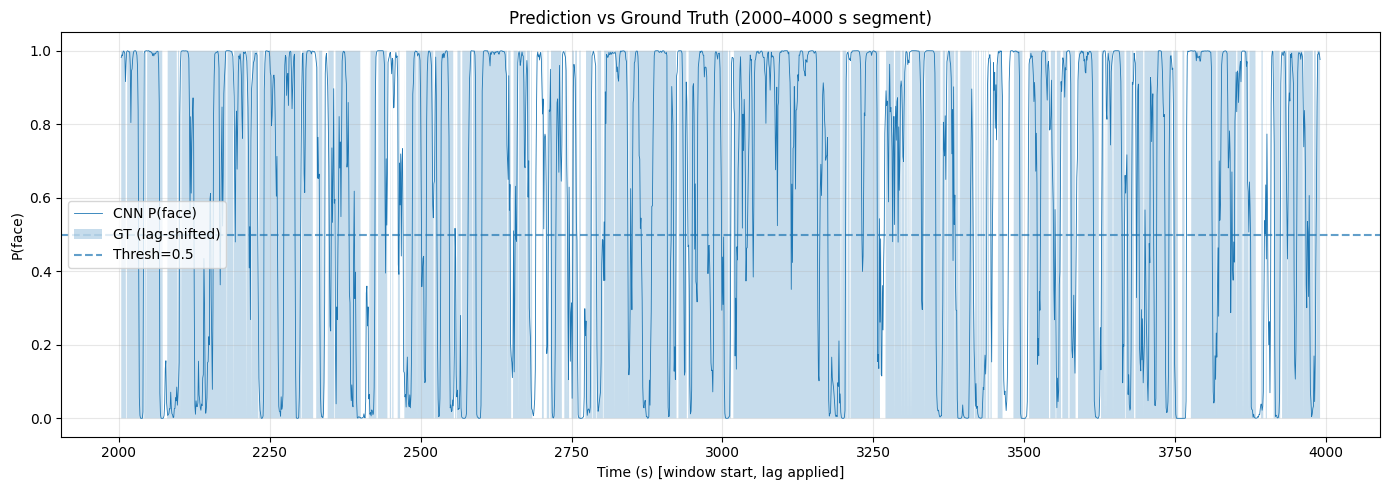

Saved: /Users/saraasadi/Desktop/fnof/results/plot_probability_2000_4000.png


In [26]:
import matplotlib.pyplot as plt

prob_png = RESULTS_DIR / "plot_probability_2000_4000.png"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(times, preds, linewidth=0.6, label="CNN P(face)")
ax.fill_between(times, 0, gt_binary, alpha=0.25, label="GT (lag-shifted)")
ax.axhline(PRED_THRESH, linestyle="--", alpha=0.7, label=f"Thresh={PRED_THRESH}")
ax.set_xlabel("Time (s) [window start, lag applied]")
ax.set_ylabel("P(face)")
ax.set_title("Prediction vs Ground Truth (2000–4000 s segment)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(prob_png, dpi=200)
plt.show()

print("Saved:", prob_png.resolve())


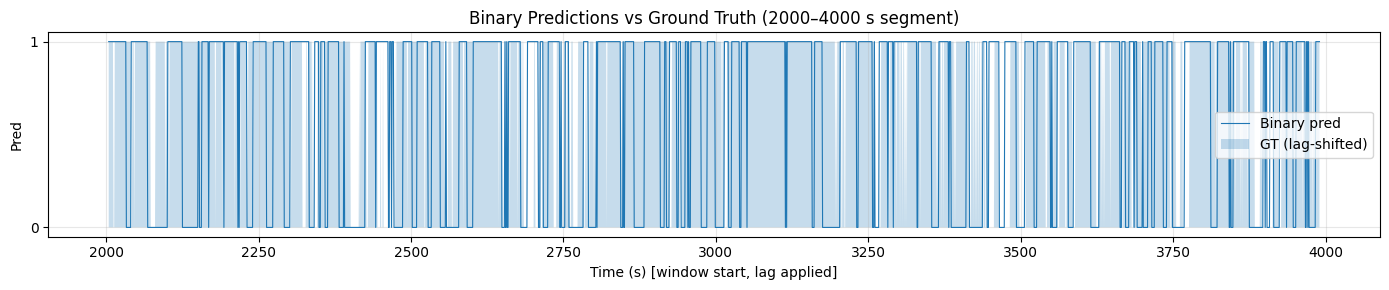

Saved: /Users/saraasadi/Desktop/fnof/results/plot_binary_2000_4000.png


In [27]:
bin_png = RESULTS_DIR / "plot_binary_2000_4000.png"

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(times, binary_preds, linewidth=0.8, label="Binary pred")
ax.fill_between(times, 0, gt_binary, alpha=0.25, label="GT (lag-shifted)")
ax.set_xlabel("Time (s) [window start, lag applied]")
ax.set_yticks([0, 1])
ax.set_ylabel("Pred")
ax.set_title("Binary Predictions vs Ground Truth (2000–4000 s segment)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(bin_png, dpi=200)
plt.show()

print("Saved:", bin_png.resolve())


In [28]:
# show top 20 predicted windows
topk = 20
idx = np.argsort(-preds)[:topk]

print("Top predicted windows:")
for i in idx:
    print(f"t={times[i]:.1f}s  P={preds[i]:.3f}  GT={gt_binary[i]}  bin={binary_preds[i]}")


Top predicted windows:
t=2435.0s  P=1.000  GT=1  bin=1
t=2434.0s  P=1.000  GT=1  bin=1
t=2436.0s  P=1.000  GT=1  bin=1
t=3342.0s  P=1.000  GT=1  bin=1
t=3341.0s  P=1.000  GT=1  bin=1
t=3343.0s  P=1.000  GT=1  bin=1
t=3653.0s  P=1.000  GT=1  bin=1
t=3340.0s  P=1.000  GT=1  bin=1
t=2433.0s  P=1.000  GT=1  bin=1
t=3654.0s  P=1.000  GT=1  bin=1
t=2180.0s  P=1.000  GT=1  bin=1
t=3316.0s  P=1.000  GT=1  bin=1
t=2182.0s  P=1.000  GT=1  bin=1
t=2181.0s  P=1.000  GT=1  bin=1
t=3105.0s  P=1.000  GT=1  bin=1
t=3655.0s  P=1.000  GT=1  bin=1
t=3106.0s  P=1.000  GT=1  bin=1
t=3652.0s  P=1.000  GT=1  bin=1
t=3339.0s  P=1.000  GT=1  bin=1
t=3344.0s  P=1.000  GT=1  bin=1
